# Visualización de partículas en \(x,y,z\)

Este notebook lee las posiciones finales de las partículas escritas por el código Fortran y genera gráficos de la distribución espacial.

Por defecto lee:

```text
output/gc_txt_particles_final.dat
```

El archivo esperado tiene columnas:

```text
# id x y z vpar mu active
```

La última columna, `active`, suele estar escrita como `T` o `F`, por lo que el notebook lee sólo las columnas numéricas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
})

## Configuración

Ejecutar este notebook desde el directorio principal del código:

```bash
cd guiding_center_txt
jupyter notebook
```

Si el notebook queda dentro de `scripts/`, cambiar `data_dir = Path("../output")`.

In [2]:
# Si ejecutás el notebook desde el directorio principal del código:
data_dir = Path("../output")

# Si lo ejecutás desde la carpeta scripts/, usar:
# data_dir = Path("../output")

prefix = "gc_txt"

particles_file = data_dir / f"{prefix}_particles_final.dat"

print("Particles file:", particles_file)
print("Existe:", particles_file.exists())

Particles file: ../output/gc_txt_particles_final.dat
Existe: True


## Leer partículas

Se leen las columnas numéricas:

\[
{\rm id},\quad x,\quad y,\quad z,\quad v_\parallel,\quad \mu.
\]

La columna lógica `active`, escrita como `T` o `F`, se ignora en esta lectura básica.

In [3]:
if not particles_file.exists():
    raise FileNotFoundError(
        f"No encontré {particles_file}. "
        "Primero corré ./gc_particles desde el directorio principal."
    )

# Formato esperado:
# id x y z vpar mu active
# Leemos sólo las primeras seis columnas numéricas.
data = np.loadtxt(particles_file, comments="#", usecols=(0, 1, 2, 3, 4, 5))

if data.ndim == 1:
    data = data.reshape(1, -1)

pid  = data[:, 0].astype(int)
x    = data[:, 1]
y    = data[:, 2]
z    = data[:, 3]
vpar = data[:, 4]
mu   = data[:, 5]

print(f"Número de partículas leídas: {len(x)}")
print(f"x: min={x.min():.6e}, max={x.max():.6e}")
print(f"y: min={y.min():.6e}, max={y.max():.6e}")
print(f"z: min={z.min():.6e}, max={z.max():.6e}")
print(f"vpar: min={vpar.min():.6e}, mean={vpar.mean():.6e}, max={vpar.max():.6e}")
print(f"mu:   min={mu.min():.6e}, mean={mu.mean():.6e}, max={mu.max():.6e}")

Número de partículas leídas: 1
x: min=1.331562e+00, max=1.331562e+00
y: min=6.022041e+00, max=6.022041e+00
z: min=-1.526256e+00, max=-1.526256e+00
vpar: min=-5.799610e+06, mean=-5.799610e+06, max=-5.799610e+06
mu:   min=2.909468e-17, mean=2.909468e-17, max=2.909468e-17


## Submuestreo para graficar

Si hay muchas partículas, graficar todas puede ser lento. Esta celda toma una muestra aleatoria de tamaño `nplot`.

In [4]:
nplot = 20000

rng = np.random.default_rng(1234)

if len(x) > nplot:
    idx = rng.choice(len(x), size=nplot, replace=False)
else:
    idx = np.arange(len(x))

xp = x[idx]
yp = y[idx]
zp = z[idx]
vpar_p = vpar[idx]
mu_p = mu[idx]

print(f"Partículas graficadas: {len(idx)}")

Partículas graficadas: 1


In [5]:
from pathlib import Path

# Cambia este nombre para guardar los graficos en output/<nombre_carpeta>
plots_folder = "T_500-bz_cte-ez_cte"

fig_dir = data_dir / plots_folder
fig_dir.mkdir(parents=True, exist_ok=True)

## Gráfico 3D de partículas

Cada punto representa la posición final de un centro guía.

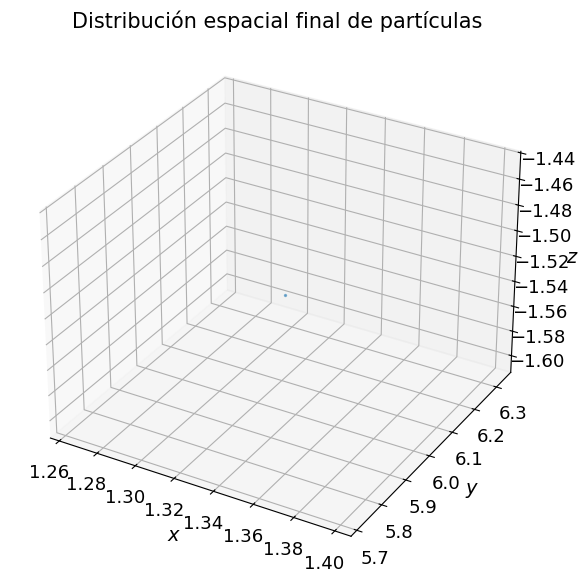

In [6]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(xp, yp, zp, s=2, alpha=0.5)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title("Distribución espacial final de partículas")

fig.tight_layout()
plt.show()

## Gráfico 3D coloreado por \(v_\parallel\)

Este gráfico ayuda a ver si existe una correlación espacial con la velocidad paralela.

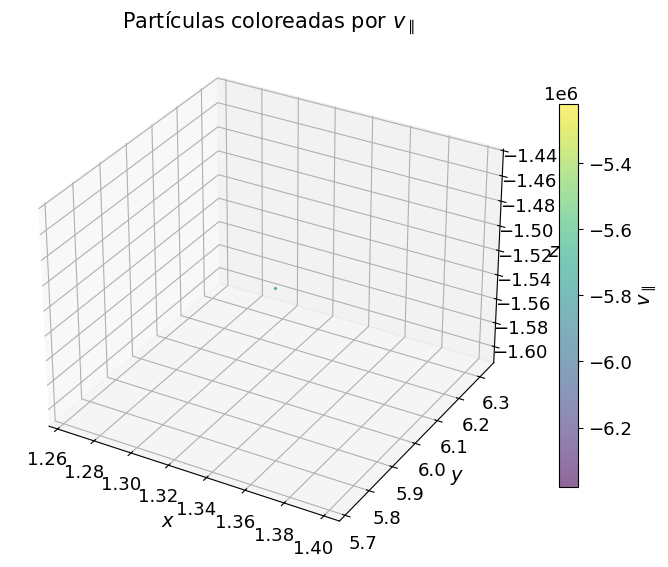

In [7]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(xp, yp, zp, c=vpar_p, s=2, alpha=0.6)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title(r"Partículas coloreadas por $v_\parallel$")

cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label(r"$v_\parallel$")

fig.tight_layout()
plt.show()

## Proyección \(x-y\)

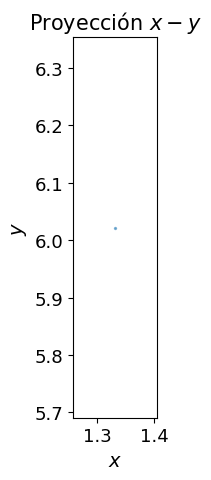

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(xp, yp, s=2, alpha=0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Proyección $x-y$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Proyección \(x-z\)

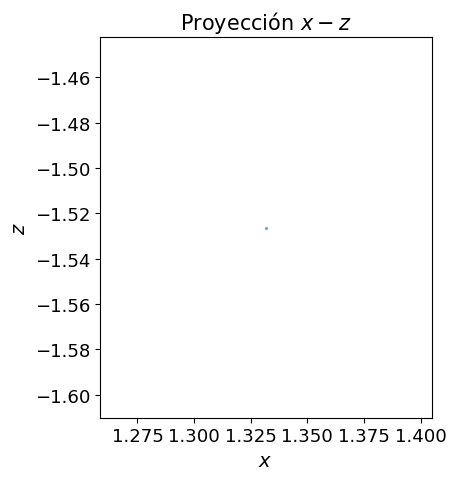

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(xp, zp, s=2, alpha=0.5)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title(r"Proyección $x-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Proyección \(y-z\)

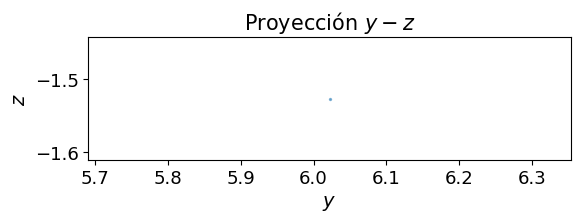

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(yp, zp, s=2, alpha=0.5)
plt.xlabel(r"$y$")
plt.ylabel(r"$z$")
plt.title(r"Proyección $y-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Histogramas 1D de posiciones

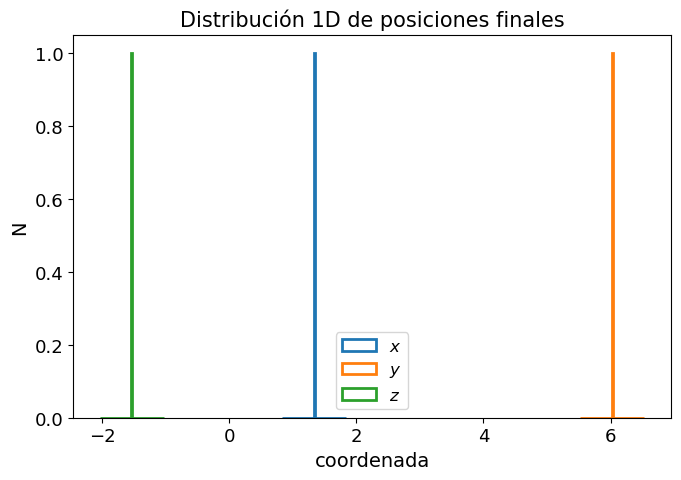

In [11]:
nbins = 80

plt.figure(figsize=(7, 5))
plt.hist(x, bins=nbins, histtype="step", linewidth=2, label=r"$x$")
plt.hist(y, bins=nbins, histtype="step", linewidth=2, label=r"$y$")
plt.hist(z, bins=nbins, histtype="step", linewidth=2, label=r"$z$")
plt.xlabel("coordenada")
plt.ylabel("N")
plt.title("Distribución 1D de posiciones finales")
plt.legend()
plt.tight_layout()
plt.show()

## Mapas 2D de densidad proyectada

Si hay muchas partículas, los histogramas 2D son más informativos que los scatter plots.

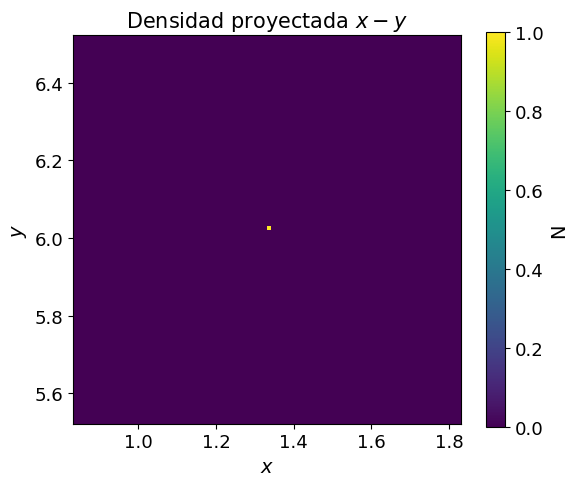

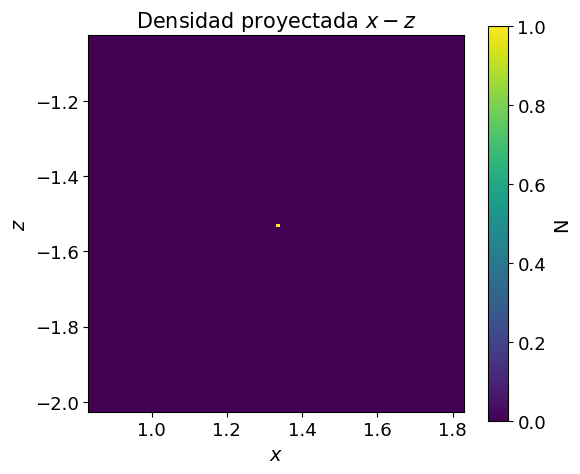

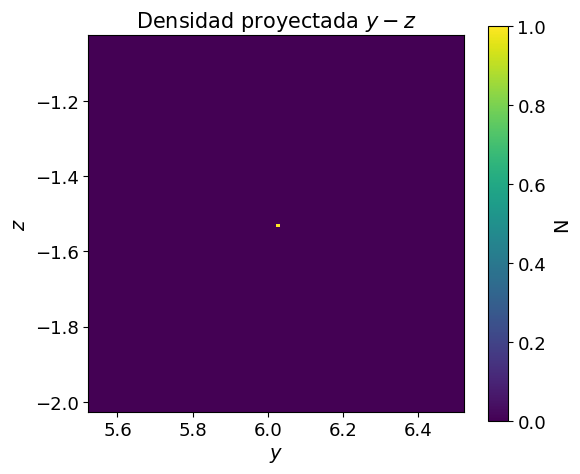

In [12]:
nbins2d = 100

plt.figure(figsize=(6, 5))
plt.hist2d(x, y, bins=nbins2d)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title(r"Densidad proyectada $x-y$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist2d(x, z, bins=nbins2d)
plt.xlabel(r"$x$")
plt.ylabel(r"$z$")
plt.title(r"Densidad proyectada $x-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist2d(y, z, bins=nbins2d)
plt.xlabel(r"$y$")
plt.ylabel(r"$z$")
plt.title(r"Densidad proyectada $y-z$")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(label="N")
plt.tight_layout()
plt.show()

## Guardar figuras

Esta celda guarda un gráfico 3D y las tres proyecciones.

In [13]:
fig_dir = data_dir / plots_folder
fig_dir.mkdir(parents=True, exist_ok=True)

fig3d = fig_dir / f"{prefix}_particles_xyz_3d.png"
figvpar = fig_dir / f"{prefix}_particles_vpar_3d.png"
figxy = fig_dir / f"{prefix}_particles_xy.png"
figxz = fig_dir / f"{prefix}_particles_xz.png"
figyz = fig_dir / f"{prefix}_particles_yz.png"
fighist = fig_dir / f"{prefix}_hist_pos_1d.png"
figdens_xy = fig_dir / f"{prefix}_dens_xy.png"
figdens_xz = fig_dir / f"{prefix}_dens_xz.png"
figdens_yz = fig_dir / f"{prefix}_dens_yz.png"

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xp, yp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title("Distribución espacial final de partículas")
fig.tight_layout()
fig.savefig(fig3d, dpi=200)
plt.close(fig)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(xp, yp, zp, c=vpar_p, s=2, alpha=0.6)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title(r"Partículas coloreadas por $v_\parallel$")
cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label(r"$v_\parallel$")
fig.tight_layout()
fig.savefig(figvpar, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xp, yp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Proyección $x-y$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figxy, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(xp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Proyección $x-z$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figxz, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(yp, zp, s=2, alpha=0.5)
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Proyección $y-z$")
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
fig.savefig(figyz, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(x, bins=nbins, histtype="step", linewidth=2, label=r"$x$")
ax.hist(y, bins=nbins, histtype="step", linewidth=2, label=r"$y$")
ax.hist(z, bins=nbins, histtype="step", linewidth=2, label=r"$z$")
ax.set_xlabel("coordenada")
ax.set_ylabel("N")
ax.set_title("Distribución 1D de posiciones finales")
ax.legend()
fig.tight_layout()
fig.savefig(fighist, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist2d(x, y, bins=nbins2d)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(r"Densidad proyectada $x-y$")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(ax.collections[0], ax=ax, label="N")
fig.tight_layout()
fig.savefig(figdens_xy, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist2d(x, z, bins=nbins2d)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Densidad proyectada $x-z$")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(ax.collections[0], ax=ax, label="N")
fig.tight_layout()
fig.savefig(figdens_xz, dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist2d(y, z, bins=nbins2d)
ax.set_xlabel(r"$y$")
ax.set_ylabel(r"$z$")
ax.set_title(r"Densidad proyectada $y-z$")
ax.set_aspect("equal", adjustable="box")
fig.colorbar(ax.collections[0], ax=ax, label="N")
fig.tight_layout()
fig.savefig(figdens_yz, dpi=200)
plt.close(fig)

print("Figuras guardadas en:")
print(fig3d)
print(figvpar)
print(figxy)
print(figxz)
print(figyz)
print(fighist)
print(figdens_xy)
print(figdens_xz)
print(figdens_yz)

Figuras guardadas en:
../output/T_500-bz_cte-ez_cte/gc_txt_particles_xyz_3d.png
../output/T_500-bz_cte-ez_cte/gc_txt_particles_vpar_3d.png
../output/T_500-bz_cte-ez_cte/gc_txt_particles_xy.png
../output/T_500-bz_cte-ez_cte/gc_txt_particles_xz.png
../output/T_500-bz_cte-ez_cte/gc_txt_particles_yz.png
../output/T_500-bz_cte-ez_cte/gc_txt_hist_pos_1d.png
../output/T_500-bz_cte-ez_cte/gc_txt_dens_xy.png
../output/T_500-bz_cte-ez_cte/gc_txt_dens_xz.png
../output/T_500-bz_cte-ez_cte/gc_txt_dens_yz.png


## DISTRIBUCIONES DE ENERGÍA

In [14]:
prefix = 'gc_txt'

data_outdir = data_dir
plot_outdir = fig_dir

energy_file = data_outdir / f'{prefix}_energy_table.dat'
hist_file = data_outdir / f'{prefix}_energy_histogram.dat'

if not energy_file.exists():
    raise FileNotFoundError(energy_file)

#data = np.loadtxt(energy_file, comments='#')
data = np.loadtxt(energy_file, comments="#", usecols=(0, 1, 2))
# Format: id E_initial E_final active
E_initial = data[:, 1]
E_final = data[:, 2]
mask = (E_initial >= 0.0) & (E_final >= 0.0)
E_initial = E_initial[mask]
E_final = E_final[mask]

print(f'Particles used: {len(E_initial)}')
print(f'E_initial mean = {E_initial.mean():.8e}')
print(f'E_final   mean = {E_final.mean():.8e}')
print(f'mean dE/E      = {np.mean((E_final-E_initial)/E_initial):.8e}')

nbins = 80
emin = min(E_initial.min(), E_final.min())
emax = max(E_initial.max(), E_final.max())
if emin == emax:
    delta = 0.5*abs(emin) if emin != 0.0 else 0.5
    emin -= delta
    emax += delta
bins = np.linspace(emin, emax, nbins+1)

plt.figure(figsize=(7,5))
plt.hist(E_initial, bins=bins, histtype='step', linewidth=2, label='Inicial')
plt.hist(E_final, bins=bins, histtype='step', linewidth=2, label='Final')
plt.xlabel(r'$E_{\rm kin}$')
plt.ylabel(r'$N(E)$')
plt.legend()
plt.tight_layout()
fig = plot_outdir / f'{prefix}_energy_distribution.png'
plt.savefig(fig, dpi=200)
print(f'Wrote {fig}')

if hist_file.exists():
    h = np.loadtxt(hist_file, comments='#')
    plt.figure(figsize=(7,5))
    plt.step(h[:,0], h[:,1], where='mid', linewidth=2, label='Inicial')
    plt.step(h[:,0], h[:,2], where='mid', linewidth=2, label='Final')
    plt.xlabel(r'$E_{\rm kin}$')
    plt.ylabel(r'$N(E)$')
    plt.legend()
    plt.tight_layout()
    fig2 = plot_outdir / f'{prefix}_energy_histogram_from_fortran.png'
    plt.savefig(fig2, dpi=200)
    print(f'Wrote {fig2}')

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# Trayectorias de partículas

trajectory_file = data_dir / f"{prefix}_trajectories.dat"
print("Trajectory file:", trajectory_file)

if not trajectory_file.exists():
    raise FileNotFoundError(
        f"No encontré {trajectory_file}. Primero corré la simulación con write_trajectories = .true."
    )

# Formato esperado desde Fortran:
# step time id x y z active
# Leemos sólo las columnas numéricas y dejamos active afuera.
traj = np.loadtxt(trajectory_file, comments="#", usecols=(0, 1, 2, 3, 4, 5))

if traj.ndim == 1:
    traj = traj.reshape(1, -1)

step = traj[:, 0].astype(int)
time = traj[:, 1]
pid_traj = traj[:, 2].astype(int)
x_traj = traj[:, 3]
y_traj = traj[:, 4]
z_traj = traj[:, 5]

available_ids = np.unique(pid_traj)
print("IDs disponibles:", available_ids)

track_id = int(available_ids[0])
print("ID graficado:", track_id)

mask = pid_traj == track_id
step_sel = step[mask]
time_sel = time[mask]
x_sel = x_traj[mask]
y_sel = y_traj[mask]
z_sel = z_traj[mask]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_sel, y_sel, z_sel, s=20)
ax.scatter(x_sel[0], y_sel[0], z_sel[0], c="green", s=50, label="inicio")
ax.scatter(x_sel[-1], y_sel[-1], z_sel[-1], c="red", s=50, label="fin")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$z$")
ax.set_title(f"Trayectoria 3D de la partícula {track_id}")
ax.legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
axes[0].scatter(time_sel, x_sel, s=20)
axes[0].set_ylabel(r"$x(t)$")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(time_sel, y_sel, s=20)
axes[1].set_ylabel(r"$y(t)$")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(time_sel, z_sel, s=20)
axes[2].set_ylabel(r"$z(t)$")
axes[2].set_xlabel(r"$t$")
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Componentes temporales de la partícula {track_id}")
fig.tight_layout()
plt.show()